## Explainability

Explain why the model makes its predictions using SHAP

- bar plot (global)
- beeswarm plot (global)
- waterfall plot (local, on high, medium and low risk)
- dependence plot (feature interaction)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import json
import warnings
import os
warnings.filterwarnings('ignore')

# SHAP
import shap
shap.initjs()  # enables JS plots in Jupyter

# Fairlearn
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    false_positive_rate,
    false_negative_rate,
    true_positive_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED   = 42
TARGET = 'is_canceled'
print('Libraries loaded.')

Libraries loaded.


### load artifacts 

In [2]:
# load best model and data
model = joblib.load('./models/best/best_model.pkl')
encoder = joblib.load('./models/ordinal_encoder.pkl')

with open('./models/best/best_model_meta.json') as f:
    meta = json.load(f)

with open('./data/feature_sets/feature_sets.json', 'r', encoding='utf-8') as f:
    feature_sets = json.load(f)

best_feature_set = meta["feature_set"]
selected_features = feature_sets[best_feature_set]

print(f'Model loaded: {meta.get("model_key", "best_model")}')
print(f'Model type: {type(model).__name__}')
print(f'Metadata: {json.dumps(meta, indent=2)}')

print("Best feature set:", best_feature_set)
print("N selected features:", len(selected_features))

Model loaded: best_model
Model type: XGBClassifier
Metadata: {
  "saved_at": "2026-04-03T23:05:43.100449",
  "best_model_key": "XGB_after_variance_unbal_xgb",
  "model_name": "XGB",
  "feature_set": "after_variance",
  "balanced": false,
  "source": "xgb",
  "threshold": 0.6000000000000001,
  "target": "is_canceled",
  "metrics": {
    "test_accuracy": 0.8367804205446397,
    "test_auc": 0.9050675038358027,
    "test_pr_auc": 0.7976237994121552,
    "test_f1": 0.7212793093299323,
    "test_precision": 0.6803627614288358,
    "test_recall": 0.7674321503131524
  }
}
Best feature set: after_variance
N selected features: 46


In [3]:
# load data

df = pd.read_csv('./data/hotel_bookings_feature_engineered.csv')
print('Loaded: ./data/hotel_bookings_feature_engineered.csv')


print(f'Shape: {df.shape}')

Loaded: ./data/hotel_bookings_feature_engineered.csv
Shape: (87029, 67)


In [4]:
SEED = 42
TARGET = "is_canceled"

In [5]:
DROP_COLS = [
    'reservation_status', 'reservation_status_date', 'arrival_date',
    'arrival_weekday', 'lead_time_bucket', 'country',
    'country_code_iso3', 'agent', 'company',        
]
df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()

# split
X_raw = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y
)

In [6]:
# encode using fitted encoder from model dev
cat_cols = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

X_train_cat = pd.DataFrame(
    encoder.transform(X_train_raw[cat_cols]),
    columns=cat_cols,
    index=X_train_raw.index
)
X_test_cat = pd.DataFrame(
    encoder.transform(X_test_raw[cat_cols]),
    columns=cat_cols,
    index=X_test_raw.index
)

X_train = pd.concat([X_train_raw[num_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test_raw[num_cols], X_test_cat], axis=1)

In [7]:
# select features from saved feature set
selected_features = [c for c in selected_features if c in X_train.columns]
X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

# preds
threshold = meta.get("threshold", 0.5)
y_proba = model.predict_proba(X_test_sel)[:, 1]
y_pred = (y_proba >= threshold).astype(int)

print("X_train_sel:", X_train_sel.shape)
print("X_test_sel :", X_test_sel.shape)


X_train_sel: (69623, 46)
X_test_sel : (17406, 46)


### SHAP setup and value computation

use `TreeExplainer` for XGBoost (tree based model).

SHAP: For each prediction, each feature gets a SHAP value representing how much that feature pushed the prediction away from the average prediction. Positive = pushed toward cancellation, Negative = pushed away from cancellation.

In [8]:
# create shap explainer using training data as background
background = shap.sample(X_train_sel, 500, random_state=SEED)

explainer = shap.TreeExplainer(
    model,
    data = background,
    model_output = 'probability'
)

print('SHAP TreeExplainer created.')
print(f'Expected value (base rate): {explainer.expected_value:.4f}')
print(f'This means: without any feature info, model predicts {explainer.expected_value*100:.1f}% cancellation probability')

SHAP TreeExplainer created.
Expected value (base rate): 0.3543
This means: without any feature info, model predicts 35.4% cancellation probability


In [9]:
# compute shap on test set
# sample test set
X_test_sample = X_test_sel.sample(2000, random_state=SEED)

print('Computing SHAP values...')
shap_explanation = explainer(X_test_sample)
shap_values = shap_explanation.values

print(f'SHAP values shape: {shap_values.shape}')
print(f'Rows = {shap_values.shape[0]} (sampled test bookings)')
print(f'Columns = {shap_values.shape[1]} (one SHAP value per feature per booking)')

Computing SHAP values...


 99%|===================| 1975/2000 [01:19<00:01]        

SHAP values shape: (2000, 46)
Rows = 2000 (sampled test bookings)
Columns = 46 (one SHAP value per feature per booking)


In [10]:
# check shap values + base value should approximate model probability
shap_sum  = shap_values.sum(axis=1) + explainer.expected_value
model_out = model.predict_proba(X_test_sample)[:, 1]
max_error = np.abs(shap_sum - model_out).max()
# should be near 0
print(f'max reconstruction error: {max_error:.6f}')

max reconstruction error: 0.000001


### Global Explanation (bar plot)

Shows the average absolute SHAP value per feature: on average, how much does each feature move the prediction.

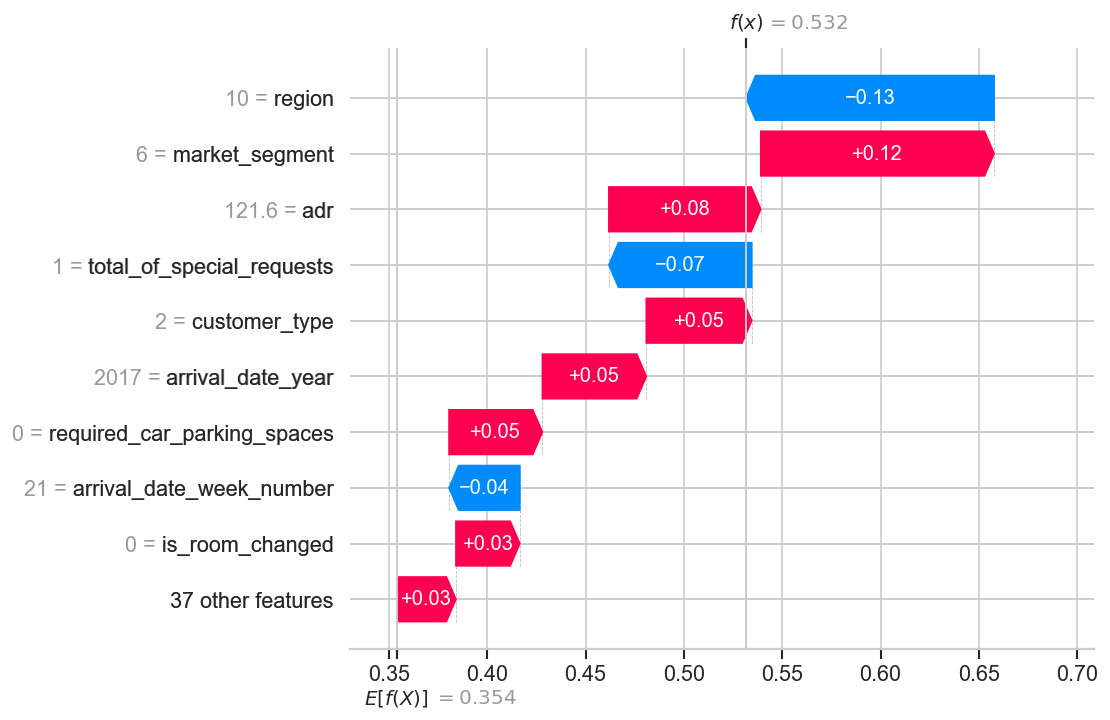

In [11]:
shap.plots.waterfall(shap_explanation[0], max_display=10)

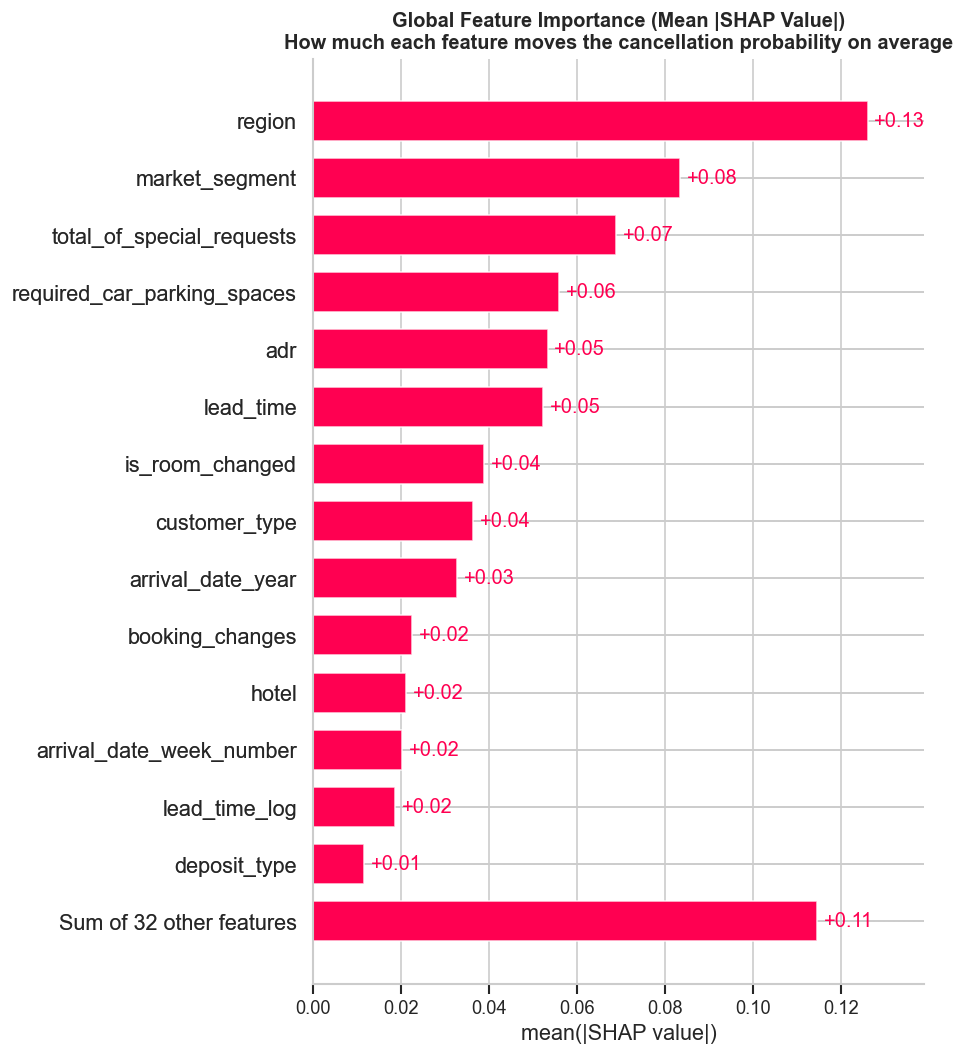

In [12]:
# global bar plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.bar(
    shap_explanation,
    max_display = 15,
    show = False
)
plt.title('Global Feature Importance (Mean |SHAP Value|)\n'
          'How much each feature moves the cancellation probability on average',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('explanation_visuals/40_shap_global_bar.png', bbox_inches='tight')
plt.show()

the plot shows how strongly each feature affects prediction (absolute value of the shap)
- region is the most influentia feature (0.13)
- many small features contribute together with 0.11
- this plot doesnt how positive or negative cuz of absolute value

In [13]:
# print ranked importance
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test_sample.columns
).sort_values(ascending=False)

print('Feature Importance Ranking (Mean |SHAP|):')
for rank, (feat, val) in enumerate(mean_abs_shap.items(), 1):
    print(f'  {rank:>2}. {feat:<45} {val:.5f}')

Feature Importance Ranking (Mean |SHAP|):
   1. region                                        0.12593
   2. market_segment                                0.08343
   3. total_of_special_requests                     0.06887
   4. required_car_parking_spaces                   0.05596
   5. adr                                           0.05333
   6. lead_time                                     0.05223
   7. is_room_changed                               0.03891
   8. customer_type                                 0.03642
   9. arrival_date_year                             0.03275
  10. booking_changes                               0.02260
  11. hotel                                         0.02125
  12. arrival_date_week_number                      0.02030
  13. lead_time_log                                 0.01865
  14. deposit_type                                  0.01163
  15. prev_cancel_ratio                             0.01070
  16. distribution_channel                          0.0095

### global explanation (beeswarm plot)
shows which direction the features impact the prediction. 
Each dot is one booking. 
Color = feature value (red = high, blue = low). 
Position = SHAP impact.

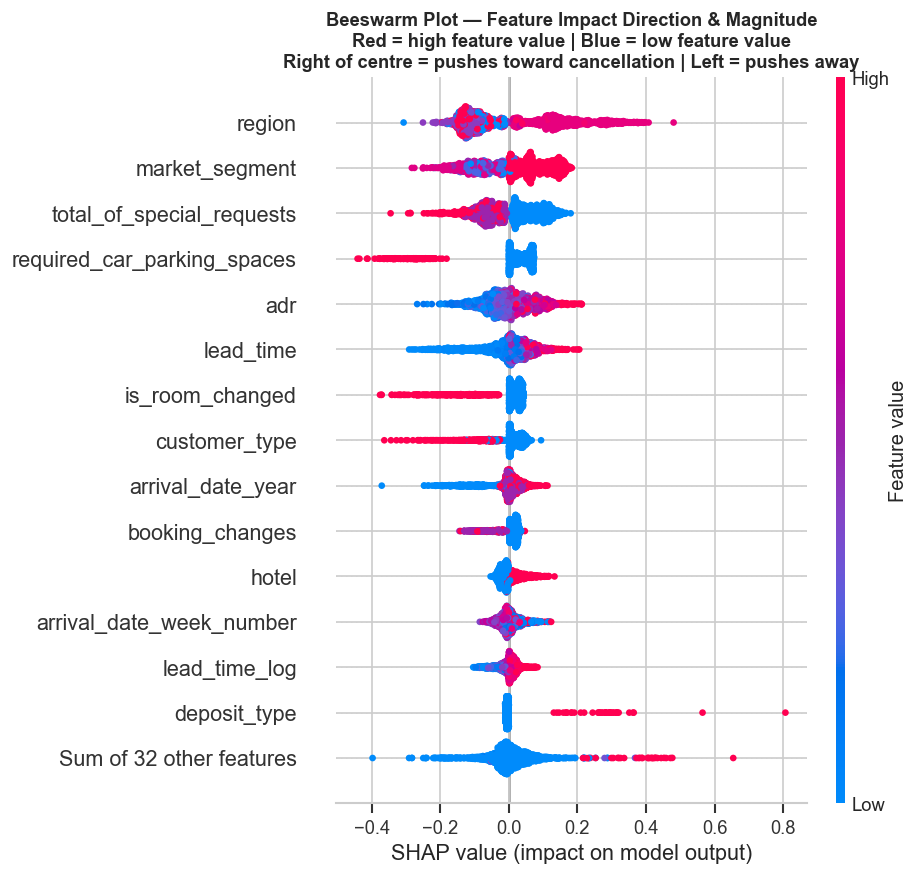

In [14]:
# beeswarm plot
fig, ax = plt.subplots(figsize=(11, 8))
shap.plots.beeswarm(
    shap_explanation,
    max_display = 15,
    show        = False
)
plt.title('Beeswarm Plot — Feature Impact Direction & Magnitude\n'
          'Red = high feature value | Blue = low feature value\n'
          'Right of centre = pushes toward cancellation | Left = pushes away',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('explanation_visuals/41_shap_beeswarm.png', bbox_inches='tight')
plt.show()

HOW TO READ THIS PLOT:
- Each row = one feature, ordered by importance (most important at top)
- Each dot = one booking from the test set
- X-axis: SHAP value — how much this feature pushed cancellation probability
  - Positive (right) = increased cancellation probability
  - Negative (left)  = decreased cancellation probability
- Color: red = high value of that feature, blue = low value


The region and market segment are categorical features so the encoding needs to be translated to understand the impact

### Decode categorical encoding + category-level SHAP tables
This maps ordinal codes back to category names, then summarizes SHAP by category for `region` and `market_segment`.

In [15]:
# build code -> category lookup from fitted OrdinalEncoder
encoder_map = {}
for col, cats in zip(cat_cols, encoder.categories_):
    encoder_map[col] = {float(i): str(cat) for i, cat in enumerate(cats)}

def show_encoding_map(feature, max_rows=50):
    if feature not in encoder_map:
        print(f"Feature '{feature}' is not in encoded categorical columns.")
        return
    m = encoder_map[feature]
    df_map = pd.DataFrame({
        'encoded_value': list(m.keys()),
        'category': list(m.values())
    }).sort_values('encoded_value')
    print(f"\nEncoding map for: {feature}")
    display(df_map.head(max_rows))

show_encoding_map('region')
show_encoding_map('market_segment')
show_encoding_map('continent')



Encoding map for: region


,encoded_value,category
0,0.0,Antarctica
1,1.0,Australia and New Zealand
2,2.0,Central Asia
3,3.0,Eastern Asia
4,4.0,Eastern Europe
5,5.0,Latin America and the Caribbean
6,6.0,Melanesia
7,7.0,Micronesia
8,8.0,Northern Africa
9,9.0,Northern America



Encoding map for: market_segment


,encoded_value,category
0,0.0,Aviation
1,1.0,Complementary
2,2.0,Corporate
3,3.0,Direct
4,4.0,Groups
5,5.0,Offline TA/TO
6,6.0,Online TA
7,7.0,Undefined



Encoding map for: continent


,encoded_value,category
0,0.0,Africa
1,1.0,Americas
2,2.0,Antarctica
3,3.0,Asia
4,4.0,Europe
5,5.0,Oceania
6,6.0,Other


In [16]:
# category-level SHAP interpretation for encoded categoricals
def category_level_shap(feature, top_n=20):
    if feature not in X_test_sample.columns:
        print(f"Feature '{feature}' is not in X_test_sample (maybe not selected).")
        return None

    feat_idx = list(X_test_sample.columns).index(feature)
    tmp = pd.DataFrame({
        'encoded_value': X_test_sample[feature].astype(float).values,
        'shap_value': shap_values[:, feat_idx],
        'pred_proba': model.predict_proba(X_test_sample)[:, 1],
    }, index=X_test_sample.index)

    # prefer original raw category labels for readability
    if feature in X_test_raw.columns:
        tmp['category'] = X_test_raw.loc[X_test_sample.index, feature].astype(str).values
    else:
        lookup = encoder_map.get(feature, {})
        tmp['category'] = tmp['encoded_value'].map(lookup).fillna('UNKNOWN_OR_UNSEEN')

    summary = (
        tmp.groupby('category', dropna=False)
           .agg(
               n=('category', 'size'),
               mean_shap=('shap_value', 'mean'),
               mean_abs_shap=('shap_value', lambda s: np.abs(s).mean()),
               mean_pred_proba=('pred_proba', 'mean')
           )
           .sort_values('mean_abs_shap', ascending=False)
           .head(top_n)
    )

    print(f"\nCategory-level SHAP summary for: {feature}")
    print("mean_shap > 0 pushes toward cancellation; mean_shap < 0 pushes away")
    display(summary)
    return summary

region_shap_tbl = category_level_shap('region', top_n=20)
market_segment_shap_tbl = category_level_shap('market_segment', top_n=20)



Category-level SHAP summary for: region
mean_shap > 0 pushes toward cancellation; mean_shap < 0 pushes away


,n,mean_shap,mean_abs_shap,mean_pred_proba
category,,,,
Southern Europe,832,0.160085,0.160085,0.464340
Central Asia,1,-0.145349,0.145349,0.912288
Sub-Saharan Africa,11,0.140640,0.140640,0.650567
Australia and New Zealand,9,-0.129648,0.129648,0.125620
Northern Europe,390,-0.117045,0.117045,0.305695
Western Europe,484,-0.107339,0.107339,0.308409
Northern America,45,-0.091335,0.091335,0.255488
Eastern Europe,55,-0.086904,0.086904,0.402250
Northern Africa,8,-0.073700,0.073700,0.293630



Category-level SHAP summary for: market_segment
mean_shap > 0 pushes toward cancellation; mean_shap < 0 pushes away


,n,mean_shap,mean_abs_shap,mean_pred_proba
category,,,,
Offline TA/TO,316,-0.122088,0.122088,0.196851
Aviation,2,-0.102368,0.102368,0.417134
Groups,127,-0.083628,0.083741,0.354725
Online TA,1185,0.078932,0.079083,0.487310
Complementary,11,-0.071305,0.071305,0.198761
Direct,262,-0.067282,0.067475,0.244641
Corporate,97,-0.053052,0.054211,0.190091


1. region and market_segment are strong drivers of cancellation risk
2. High-risk region signal: Southern Europe has a strong positive SHAP (+0.160) with large sample size (n=832), so this is a robust risk segment to mention.
3. Low-risk region signals (more reliable): Northern Europe (-0.117, n=390) and Western Europe (-0.107, n=484) consistently reduce predicted cancellation risk.
4. Small-sample caution (important to say explicitly): Central Asia (n=1), Australia and New Zealand (n=9), Sub-Saharan Africa (n=11) can look extreme, but should be presented as indicative, not conclusive.
5. Market segment story (very presentation-friendly): Online TA is the only major segment pushing risk up (+0.079, n=1185, mean_pred_proba≈0.487), while Offline TA/TO, Direct, Corporate, and Groups mostly push risk down.

Commercial interpretation:
The model suggests acquisition channel and geography carry meaningful cancellation behavior differences, so a single blanket cancellation policy is suboptimal.

One-line conclusion slide:
“Cancellation risk is structurally different by region and booking channel; targeted, fairness-aware policies should outperform one-size-fits-all rules.”

### local explanation (waterfall plot)

Shows exactly how the model arrived at a prediction for one specific booking. (for presentation pick one hih risk and one low risk)

In [17]:
# high risk: model predicted cancellation with high probability
# low risk: model predicted no cancellation with high confidence

proba_sample = model.predict_proba(X_test_sample)[:, 1]

high_risk_idx = np.argmax(proba_sample) # highest cancellation probability
low_risk_idx  = np.argmin(proba_sample) # lowest cancellation probability
mid_risk_idx  = np.argmin(np.abs(proba_sample - 0.5))  # most uncertain booking

print(f'High risk booking: predicted cancel prob: {proba_sample[high_risk_idx]:.3f}')
print(f'Low risk booking: predicted cancel prob: {proba_sample[low_risk_idx]:.3f}')
print(f'Borderline booking: predicted cancel prob: {proba_sample[mid_risk_idx]:.3f}')

# show the actual booking details
print('\nHigh-risk booking features:')
display(X_test_sample.iloc[high_risk_idx])
print('\nLow-risk booking features:')
display(X_test_sample.iloc[low_risk_idx])
print('\nBorderline risk booking features:')
display(X_test_sample.iloc[mid_risk_idx])

High risk booking: predicted cancel prob: 1.000
Low risk booking: predicted cancel prob: 0.000
Borderline booking: predicted cancel prob: 0.501

High-risk booking features:


lead_time                              335.000000
arrival_date_year                     2015.000000
arrival_date_week_number                38.000000
arrival_date_day_of_month               17.000000
stays_in_weekend_nights                  0.000000
stays_in_week_nights                     1.000000
adults                                   2.000000
children                                 0.000000
babies                                   0.000000
is_repeated_guest                        0.000000
previous_cancellations                   1.000000
previous_bookings_not_canceled           0.000000
booking_changes                          0.000000
days_in_waiting_list                     0.000000
adr                                     85.000000
required_car_parking_spaces              0.000000
total_of_special_requests                0.000000
lead_time_log                            5.817111
has_children                             0.000000
has_babies                               0.000000



Low-risk booking features:


lead_time                                9.000000
arrival_date_year                     2016.000000
arrival_date_week_number                16.000000
arrival_date_day_of_month               13.000000
stays_in_weekend_nights                  0.000000
stays_in_week_nights                     1.000000
adults                                   2.000000
children                                 0.000000
babies                                   0.000000
is_repeated_guest                        1.000000
previous_cancellations                   0.000000
previous_bookings_not_canceled           3.000000
booking_changes                          1.000000
days_in_waiting_list                     0.000000
adr                                     83.000000
required_car_parking_spaces              1.000000
total_of_special_requests                1.000000
lead_time_log                            2.302585
has_children                             0.000000
has_babies                               0.000000



Borderline risk booking features:


lead_time                               14.00000
arrival_date_year                     2016.00000
arrival_date_week_number                21.00000
arrival_date_day_of_month               18.00000
stays_in_weekend_nights                  0.00000
stays_in_week_nights                     4.00000
adults                                   1.00000
children                                 0.00000
babies                                   0.00000
is_repeated_guest                        0.00000
previous_cancellations                   0.00000
previous_bookings_not_canceled           0.00000
booking_changes                          0.00000
days_in_waiting_list                     0.00000
adr                                     62.00000
required_car_parking_spaces              0.00000
total_of_special_requests                0.00000
lead_time_log                            2.70805
has_children                             0.00000
has_babies                               0.00000
has_booking_changes 

HOW TO READ THIS WATERFALL:
- Bottom: E[f(X)] = base rate (average prediction for all bookings)
- Top: f(x) = final prediction for THIS booking
- Each bar shows how much one feature CHANGED the prediction
  - Red bars (positive) = pushed probability HIGHER (toward cancellation)
  - Blue bars (negative) = pushed probability LOWER (away from cancellation)
- The bars stack up from the base rate to reach the final prediction

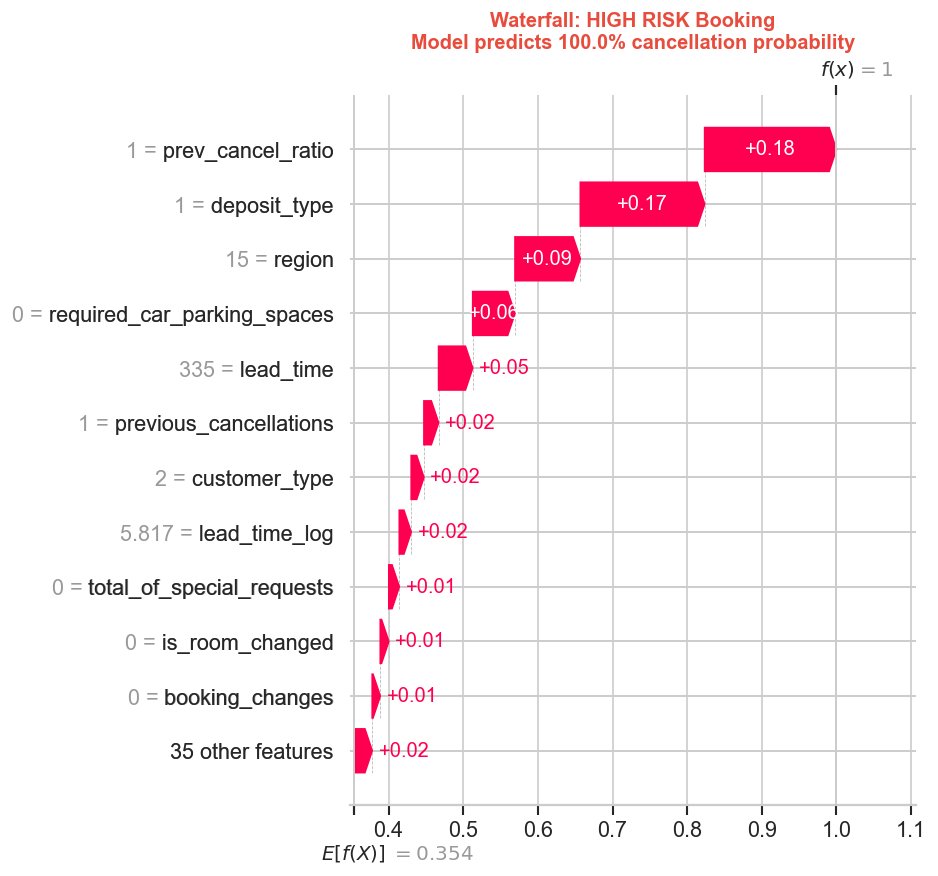

In [18]:
# waterfall for high risk booking
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(
    shap_explanation[high_risk_idx],
    max_display = 12,
    show        = False
)
plt.title(f'Waterfall: HIGH RISK Booking\n'
          f'Model predicts {proba_sample[high_risk_idx]*100:.1f}% cancellation probability',
          fontsize=12, fontweight='bold', color='#E74C3C')
plt.tight_layout()
plt.savefig('explanation_visuals/42_shap_waterfall_high_risk.png', bbox_inches='tight')
plt.show()

for this example pre_cancel_ratio and deposit type contributed the most to the prediction

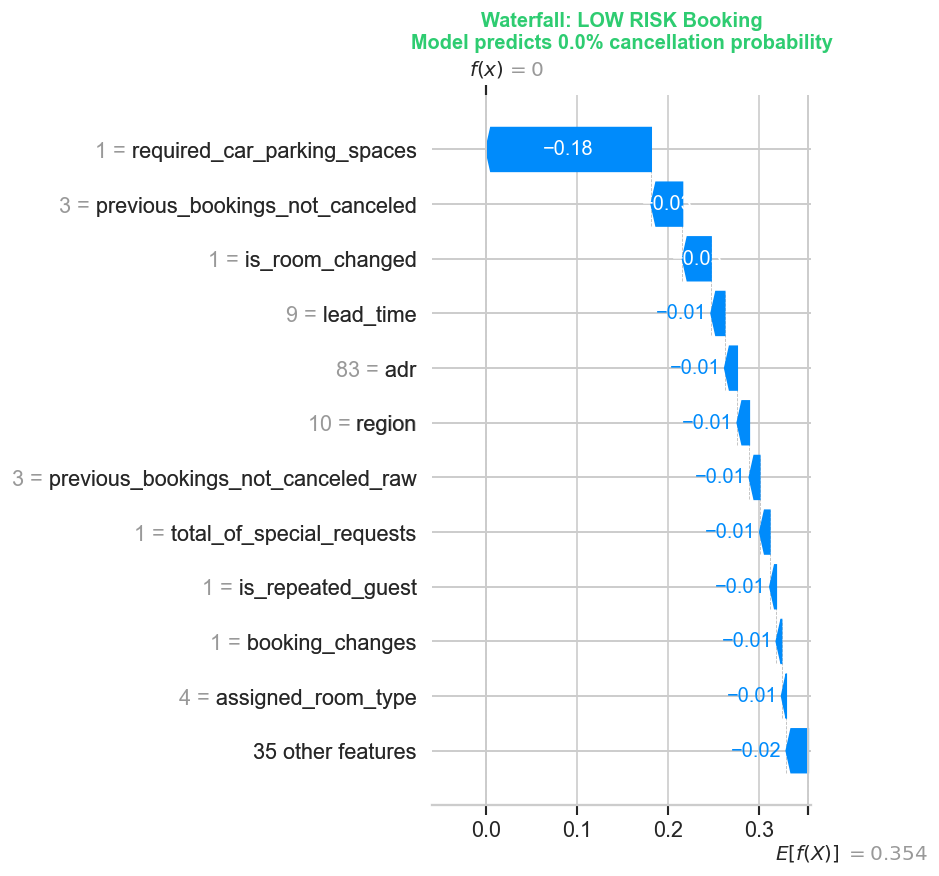

In [19]:
# waterfall for low risk booking
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(
    shap_explanation[low_risk_idx],
    max_display = 12,
    show        = False
)
plt.title(f'Waterfall: LOW RISK Booking\n'
          f'Model predicts {proba_sample[low_risk_idx]*100:.1f}% cancellation probability',
          fontsize=12, fontweight='bold', color='#2ECC71')
plt.tight_layout()
plt.savefig('explanation_visuals/43_shap_waterfall_low_risk.png', bbox_inches='tight')
plt.show()

required_parking_space has the strogest impct on the prediction (negative)

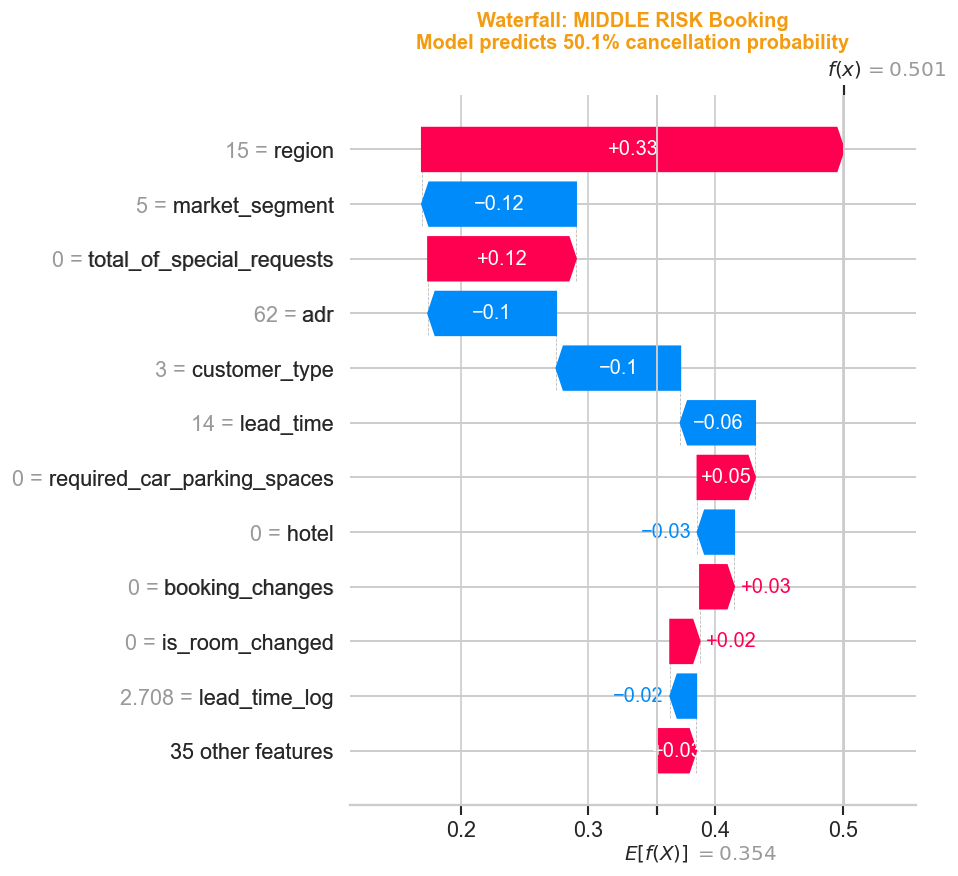

In [20]:
# waterfall for mid risk booking
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(
    shap_explanation[mid_risk_idx],
    max_display = 12,
    show        = False
)
plt.title(f'Waterfall: MIDDLE RISK Booking\n'
          f'Model predicts {proba_sample[mid_risk_idx]*100:.1f}% cancellation probability',
          fontsize=12, fontweight='bold', color='#F39C12')
plt.tight_layout()
plt.savefig('explanation_visuals/43_shap_waterfall_mid_risk.png', bbox_inches='tight')
plt.show()

- for this one region had the most impact (positive) on the prediction, 15 is Southern Europe
- segment market 5 is Offline TA/TO

### Dependence Plots

Shows how the SHAP value for one feature changes as its value increases, and whether another feature interacts with it. This reveals non-linear relationships the model has learned.

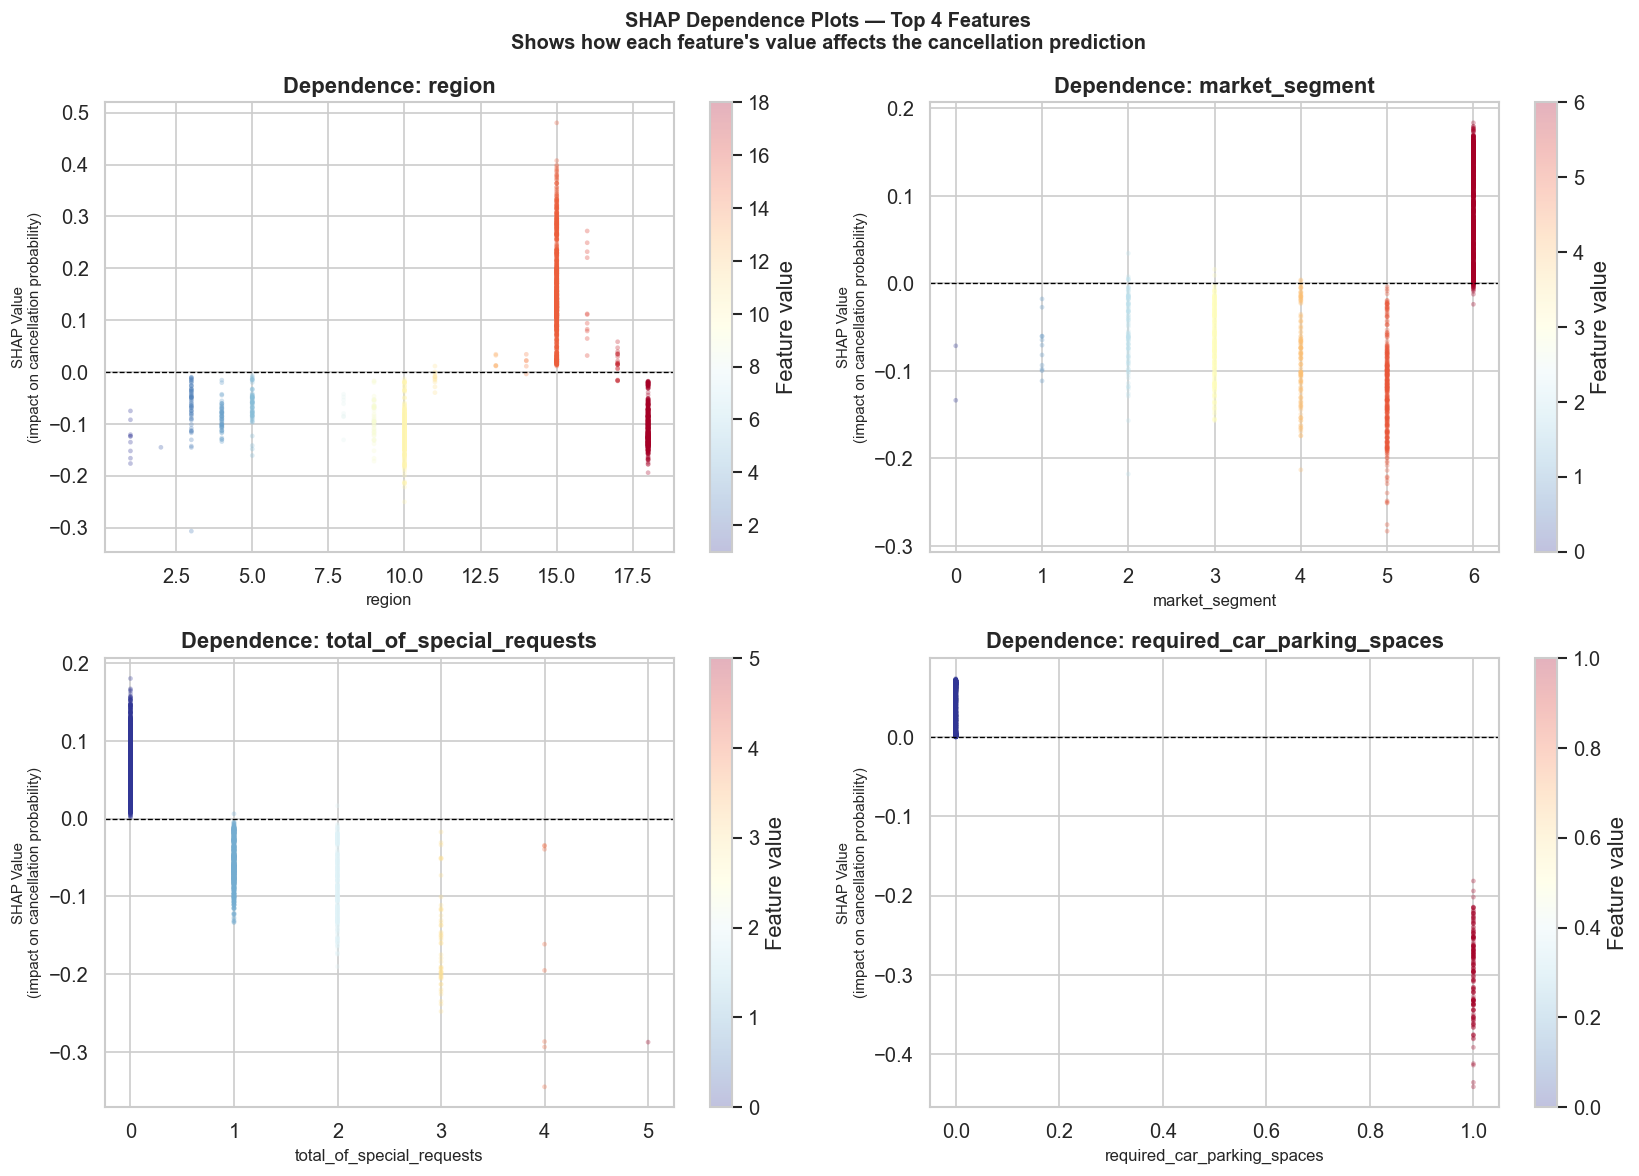

In [21]:
# dependence plots for top 4 features
top_features = mean_abs_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    if feature not in X_test_sample.columns:
        continue
    feat_idx  = list(X_test_sample.columns).index(feature)
    shap_feat = shap_values[:, feat_idx]
    feat_vals = X_test_sample[feature].values

    sc = axes[i].scatter(
        feat_vals, shap_feat,
        c=feat_vals, cmap='RdYlBu_r',
        alpha=0.3, s=8, linewidths=0
    )
    axes[i].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('SHAP Value\n(impact on cancellation probability)', fontsize=9)
    axes[i].set_title(f'Dependence: {feature}', fontweight='bold')
    plt.colorbar(sc, ax=axes[i], label='Feature value')

plt.suptitle('SHAP Dependence Plots — Top 4 Features\n'
             'Shows how each feature\'s value affects the cancellation prediction',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('explanation_visuals/45_shap_dependence.png', bbox_inches='tight')
plt.show()

- region has a strong impact (positive and negative depending on the region): 15 southern europe has high shap impact meaning that it pushes towards cancellation, other regions push towards not canceling --> sother europe is a critical region 
- market segment also: 6 Online TA pushes towards cancellation while the others push towards not canceling

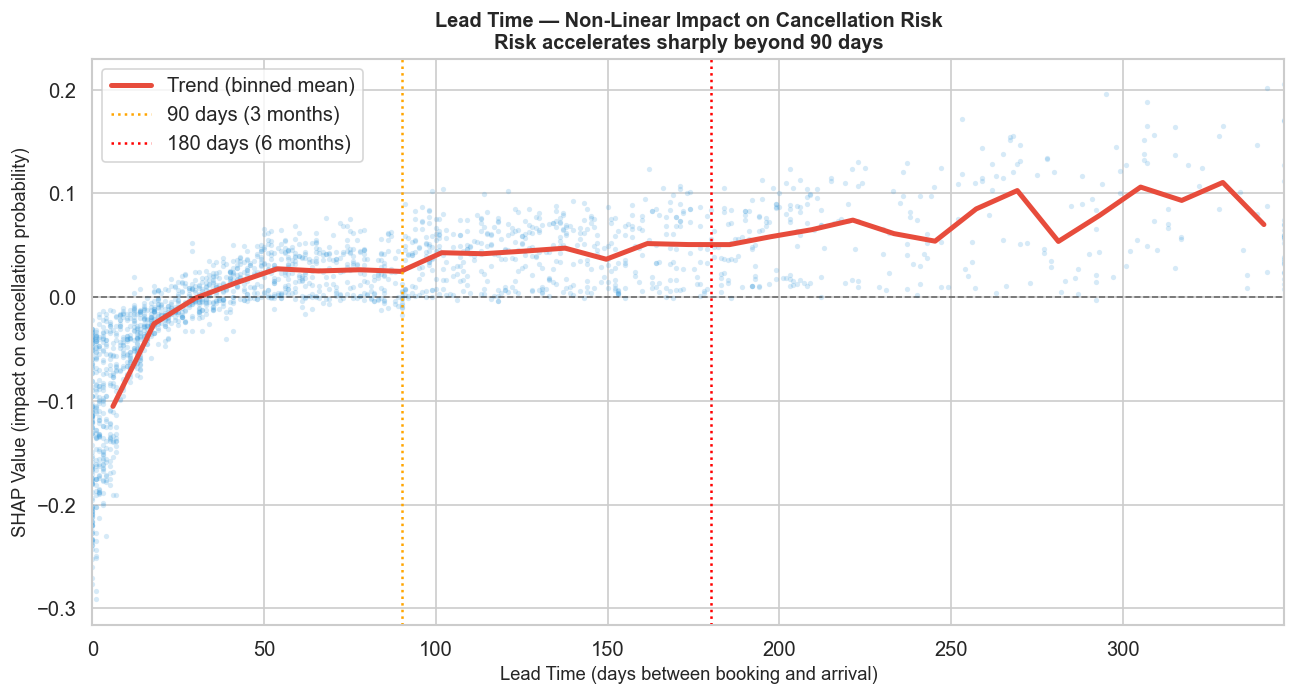

In [22]:
# ── Lead time dependence — deep dive ─────────────────────────────────────────
# This is the most important single plot for your business narrative
if 'lead_time' in X_test_sample.columns:
    lead_idx  = list(X_test_sample.columns).index('lead_time')
    lead_shap = shap_values[:, lead_idx]
    lead_vals = X_test_sample['lead_time'].values

    fig, ax = plt.subplots(figsize=(11, 6))

    # Scatter
    sc = ax.scatter(lead_vals, lead_shap,
                    alpha=0.2, s=10, c='#3498DB', linewidths=0)

    # Smoothed trend line
    from scipy.stats import binned_statistic
    bins     = np.linspace(0, min(lead_vals.max(), 500), 30)
    bin_mean, bin_edges, _ = binned_statistic(lead_vals, lead_shap,
                                               statistic='mean', bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, bin_mean, color='#E74C3C',
            linewidth=3, label='Trend (binned mean)')

    ax.axhline(y=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(x=90,  color='orange', linewidth=1.5, linestyle=':',
               label='90 days (3 months)')
    ax.axvline(x=180, color='red',    linewidth=1.5, linestyle=':',
               label='180 days (6 months)')

    ax.set_xlabel('Lead Time (days between booking and arrival)', fontsize=11)
    ax.set_ylabel('SHAP Value (impact on cancellation probability)', fontsize=11)
    ax.set_title('Lead Time — Non-Linear Impact on Cancellation Risk\n'
                 'Risk accelerates sharply beyond 90 days',
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.set_xlim(0, min(lead_vals.max(), 600))

    plt.tight_layout()
    plt.savefig('explanation_visuals/46_lead_time_dependence.png', bbox_inches='tight')
    plt.show()

lower lead time push towards not canceling while higher lead time pushes towards cancellation
- lead time impact is not linear
- very short lead times (0–15) have negative SHAP: they reduce cancellation risk
- as lead time increases, SHAP moves upward and crosses around zero: risk effect becomes neutral to positive
- around 90 days, risk is already clearly positive
- beyond roughly 180 days, the trend stays higher and generally rises: long lead-time bookings are more likely to cancel

### narrative summary

- Top global drivers: `region` and `market_segment` are the strongest contributors to cancellation predictions, followed by booking behavior features such as `total_of_special_requests`, `required_car_parking_spaces`, `adr`, and `lead_time`.
- Direction matters by category: after decoding the ordinal encoding, `region` and `market_segment` show clear group-level differences in direction (some categories push risk up, others down).
- Region signal: `Southern Europe` shows a strong positive average SHAP contribution (pushes toward cancellation), while `Northern Europe` and `Western Europe` are negative on average (push away from cancellation).
- Market segment signal: `Online TA` tends to increase cancellation risk, while `Offline TA/TO`, `Direct`, `Corporate`, and `Groups` generally decrease risk on average.
- Behavioral pattern: more `total_of_special_requests` and having `required_car_parking_spaces=1` are associated with lower cancellation risk (negative SHAP), indicating more committed bookings.
- Lead-time effect is non-linear: short lead times tend to reduce risk, while risk rises as lead time grows, with a clear acceleration after roughly 90+ days and sustained higher impact beyond ~180 days.
- Beeswarm confirms heterogeneity: wide spread around zero for top features means impact is not uniform across bookings; category and context interactions matter.
- Practical takeaway: cancellation risk is structurally different across channel/geography segments, so targeted mitigation (segment-aware policies and messaging) should outperform one-size-fits-all rules.
- Interpretation caution: categories with very small `n` in the category-level SHAP tables should be treated as directional only, not definitive evidence.

## bias analysis

analyse whether the model treats different customer groups fairly. In the hotel domain, the relevant sensitive attributes are:

- Market segment (Online TA vs Corporate vs Direct): are online bookers systematically over-flagged?
- Continent + Region (Europe vs Americas vs Asia): does guest origin affect how fairly the model treats them?
- Deposit type (No Deposit vs Non-Refund) — are guests without deposits disproportionately penalised?

Key fairness concepts:
- Demographic Parity: all groups should have similar rates of being flagged as cancelling
- Equalized Odds*: the model should make errors at similar rates across groups
- 80% Rule: a group's selection rate should be at least 80% of the highest group's rate

9. Bias Analysis — Sensitive Attributes
10. Fairlearn MetricFrame (by market segment, continent, deposit type)
11. Fairness Metrics (Demographic Parity, Equalized Odds)
12. Bias Visualisations
13. Bias Findings & Recommendations

In [23]:
# use original unencoded test set to analyze fairness across sensitive attributes
# build the same modeling base dataframe used earlier
df_orig = df.copy()
df_orig_model = df_orig.drop(columns=[c for c in DROP_COLS if c in df_orig.columns]).copy()

# recreate the same split (raw, unencoded) to recover aligned test indices
X_raw_all = df_orig_model.drop(columns=[TARGET]).copy()
y_all = df_orig_model[TARGET].copy()

X_train_raw_fair, X_test_raw_fair, y_train_fair, y_test_fair = train_test_split(
    X_raw_all,
    y_all,
    test_size=0.2,
    random_state=SEED,
    stratify=y_all
)

In [24]:
# encode test set exactly like training 
cat_cols_fair = X_train_raw_fair.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_fair = [c for c in X_train_raw_fair.columns if c not in cat_cols_fair]

X_test_cat_fair = pd.DataFrame(
    encoder.transform(X_test_raw_fair[cat_cols_fair]),
    columns=cat_cols_fair,
    index=X_test_raw_fair.index
)
X_test_enc_fair = pd.concat([X_test_raw_fair[num_cols_fair], X_test_cat_fair], axis=1)

In [25]:
# select features from saved feature set
selected_features_fair = [c for c in selected_features if c in X_test_enc_fair.columns]
X_test_model_fair = X_test_enc_fair[selected_features_fair].copy()

In [26]:
# predictions
y_pred_fair = model.predict(X_test_model_fair)
y_true_fair = y_test_fair.values

print(f"Test set size for fairness analysis: {len(y_true_fair):,}")

Test set size for fairness analysis: 17,406


In [27]:
# original
df_test_original = df_orig_model.loc[X_test_raw_fair.index].copy()

#  sensitive attributes from original values
sensitive = {}

sensitive["market_segment"] = df_test_original["market_segment"].astype(str).values
sensitive["continent"] = df_test_original["continent"].fillna("Other").astype(str).values
sensitive["deposit_type"] = df_test_original["deposit_type"].astype(str).values
sensitive["hotel"] = df_test_original["hotel"].astype(str).values

print(f"Sensitive attributes available: {list(sensitive.keys())}")
for attr, vals in sensitive.items():
    print(f"{attr}: {pd.Series(vals).value_counts().to_dict()}")

Sensitive attributes available: ['market_segment', 'continent', 'deposit_type', 'hotel']
market_segment: {'Online TA': 10289, 'Offline TA/TO': 2760, 'Direct': 2347, 'Groups': 955, 'Corporate': 854, 'Complementary': 162, 'Aviation': 39}
continent: {'Europe': 15410, 'Americas': 873, 'Asia': 774, 'Africa': 184, 'Oceania': 84, 'Other': 81}
deposit_type: {'No Deposit': 17167, 'Non Refund': 220, 'Refundable': 19}
hotel: {'City Hotel': 10536, 'Resort Hotel': 6870}


### fairlearn metricframe

In [28]:
# helper to run metricframe per attribute
def run_fairness_analysis(y_true, y_pred, sensitive_feat, feat_name):
    metrics_dict = {
        'accuracy': accuracy_score,
        'precision': lambda y, yhat: precision_score(y, yhat, zero_division=0),
        'recall': lambda y, yhat: recall_score(y, yhat, zero_division=0),
        'f1': lambda y, yhat: f1_score(y, yhat, zero_division=0),
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'false_negative_rate': false_negative_rate,
        'true_positive_rate': true_positive_rate,
    }

    mf = MetricFrame(
        metrics = metrics_dict,
        y_true = y_true,
        y_pred = y_pred,
        sensitive_features = sensitive_feat
    )

    # scalar fairness metrics
    dp_diff = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive_feat)
    dp_ratio = demographic_parity_ratio(y_true, y_pred, sensitive_features=sensitive_feat)
    eo_diff = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive_feat)
    eo_ratio = equalized_odds_ratio(y_true, y_pred, sensitive_features=sensitive_feat)

    print(f'Fairness Analysis For: {feat_name.upper()}')
    print(f'Demographic Parity Difference: {dp_diff:.4f}  (ideal = 0)')
    print(f'Demographic Parity Ratio: {dp_ratio:.4f} (ideal = 1, fair if > 0.8)')
    print(f'Equalized Odds Difference: {eo_diff:.4f}  (ideal = 0)')
    print(f'Equalized Odds Ratio: {eo_ratio:.4f} (ideal = 1)')
    print(f'\n80% Rule (DP Ratio > 0.8): {"PASS" if dp_ratio >= 0.8 else "FAIL"}')
    print(f'\nMetrics by group:')
    print(mf.by_group.round(3).to_string())
    print('\n' + '-'*50 + '\n')
    return mf, dp_diff, dp_ratio, eo_diff, eo_ratio

- dp_diff (Demographic Parity Difference):
Difference between highest and lowest selection rate across groups
Selection rate = % predicted positive
Ideal: 0 (all groups selected at same rate)

- dp_ratio (Demographic Parity Ratio):
Smallest group selection rate / largest group selection rate.
Ideal: 1. Lower means bigger disparity.

- eo_diff (Equalized Odds Difference):
Largest gap across groups in error-related rates (TPR/FPR under Fairlearn’s EO definition).
Ideal: 0 (groups have similar error behavior).

- eo_ratio (Equalized Odds Ratio):
Ratio version of equalized-odds fairness (smaller/larger rate).
Ideal: 1. Lower means worse parity.

In [29]:
# sun for each sensitive attribute
fairness_results = {}

for attr_name, attr_vals in sensitive.items():
    mf, dp_diff, dp_ratio, eo_diff, eo_ratio = run_fairness_analysis(
        y_true_fair, y_pred_fair, attr_vals, attr_name
    )
    fairness_results[attr_name] = {
        'metric_frame' : mf,
        'dp_difference': dp_diff, # demographic parity difference, ideal 0
        'dp_ratio'     : dp_ratio, # demographic parity ratio, ideal 1, fair if > 0.8
        'eo_difference': eo_diff, # equalized odds difference, ideal 0
        'eo_ratio'     : eo_ratio # equalized odds ratio, ideal 1
    }

Fairness Analysis For: MARKET_SEGMENT
Demographic Parity Difference: 0.4080  (ideal = 0)
Demographic Parity Ratio: 0.1748 (ideal = 1, fair if > 0.8)
Equalized Odds Difference: 0.5969  (ideal = 0)
Equalized Odds Ratio: 0.1762 (ideal = 1)

80% Rule (DP Ratio > 0.8): FAIL

Metrics by group:
                     accuracy  precision  recall     f1  selection_rate  false_positive_rate  false_negative_rate  true_positive_rate
sensitive_feature_0                                                                                                                  
Aviation                0.744      0.300   0.500  0.375           0.256                0.212                0.500               0.500
Complementary           0.864      0.500   0.318  0.389           0.086                0.050                0.682               0.318
Corporate               0.882      0.556   0.450  0.498           0.105                0.054                0.550               0.450
Direct                  0.854      0.507 

### fairness visualisations

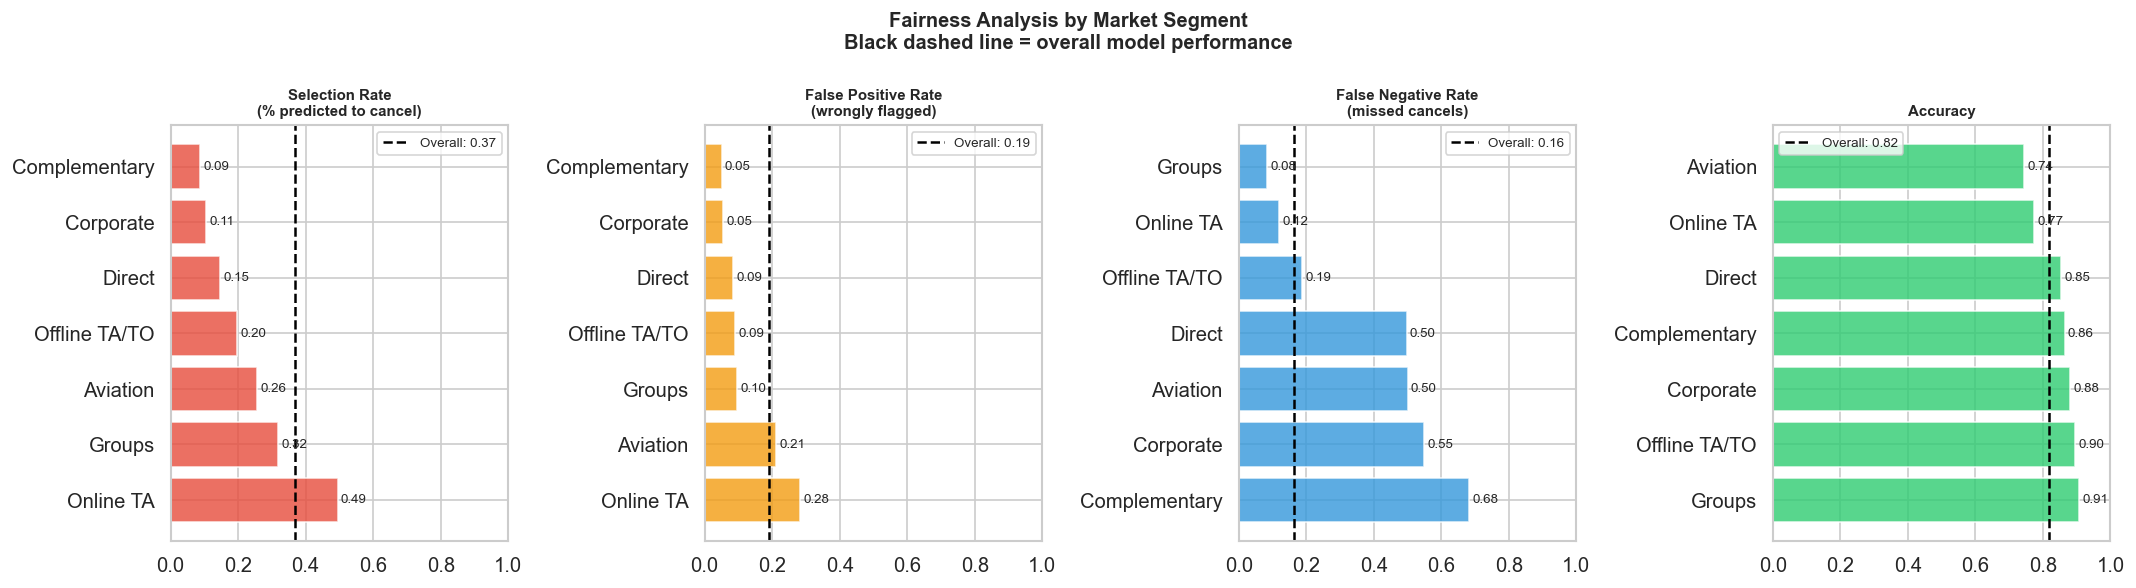

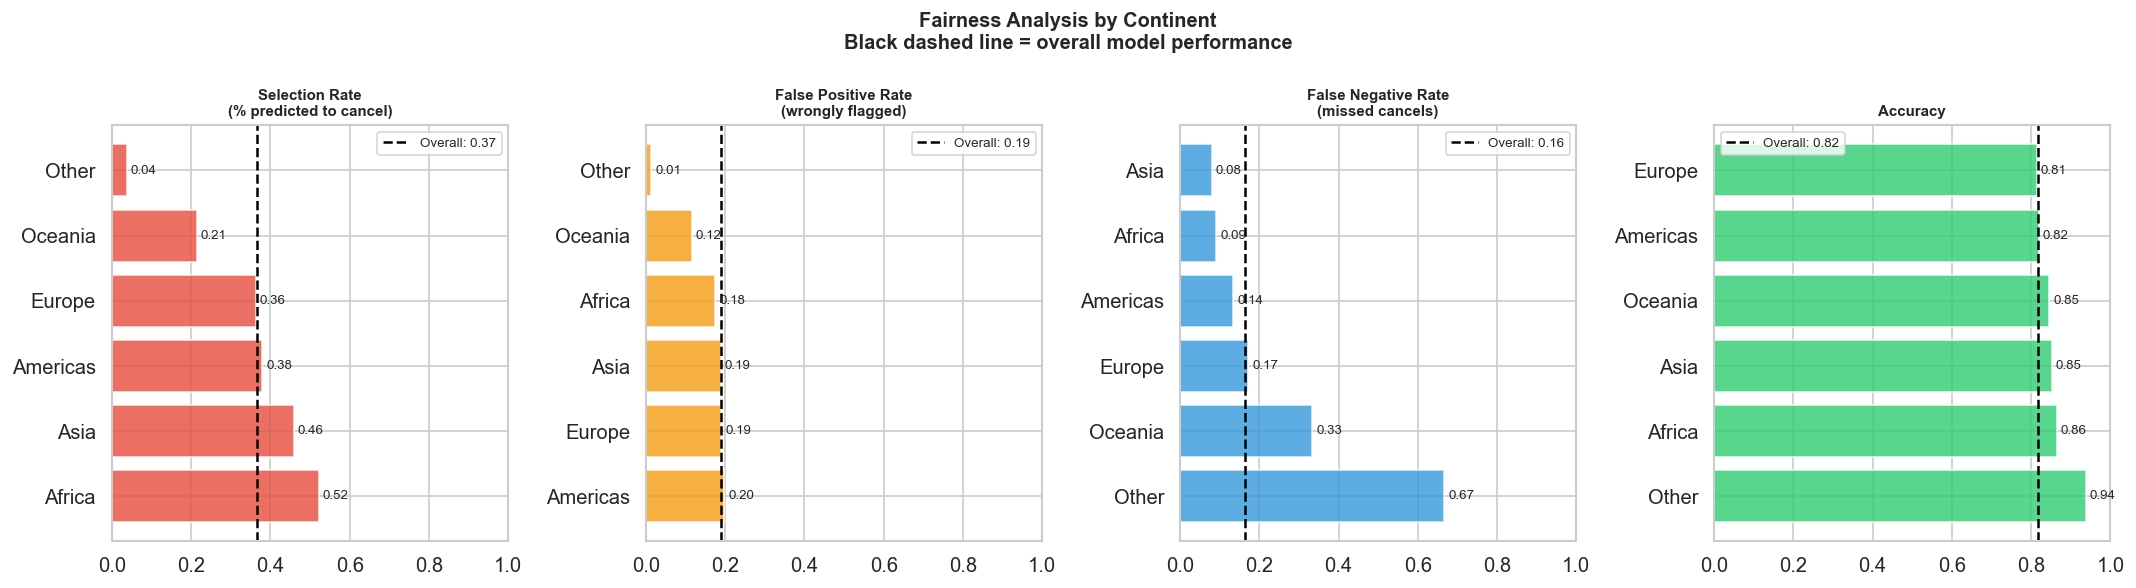

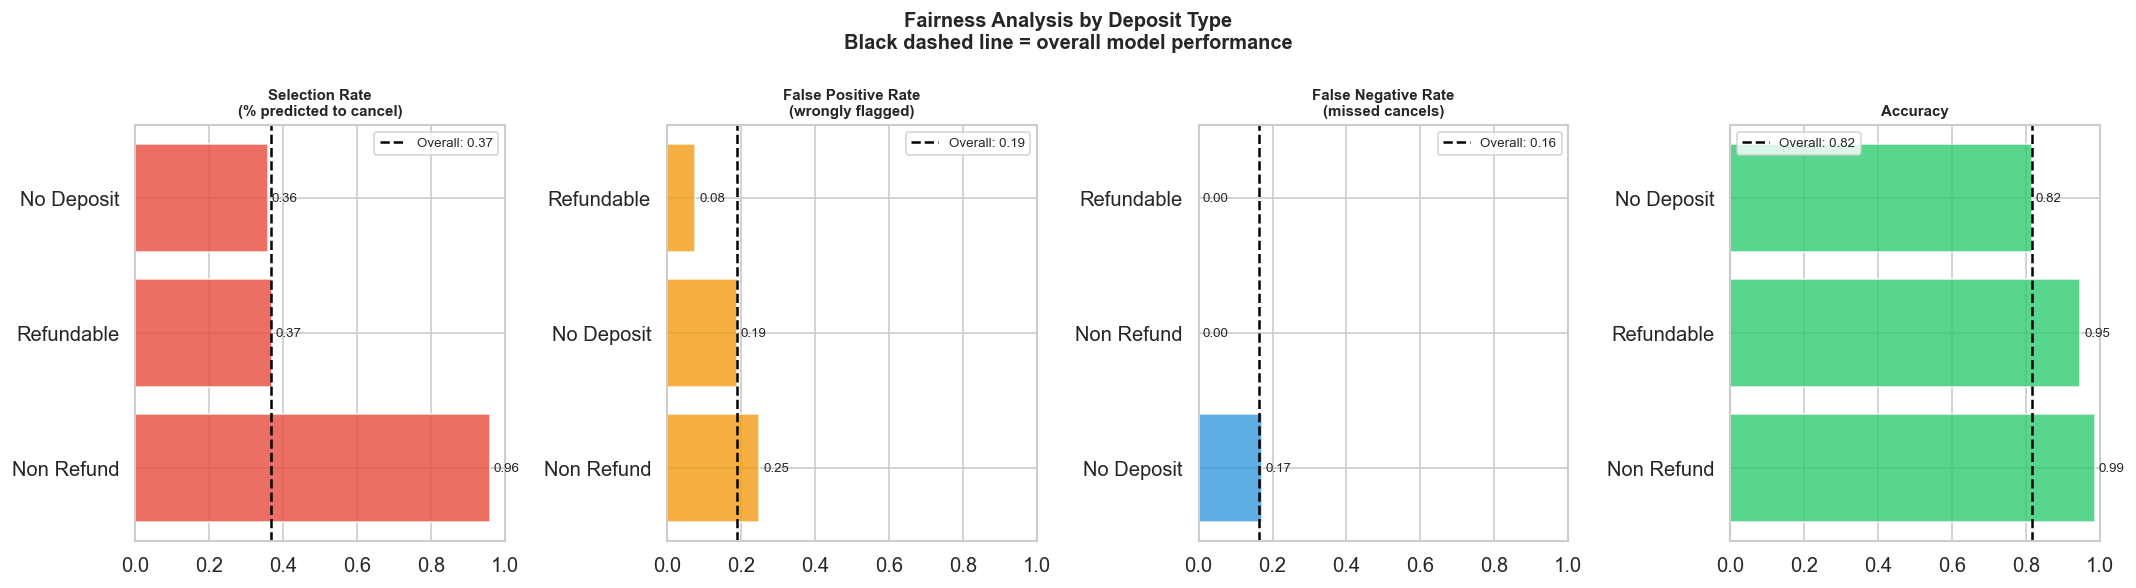

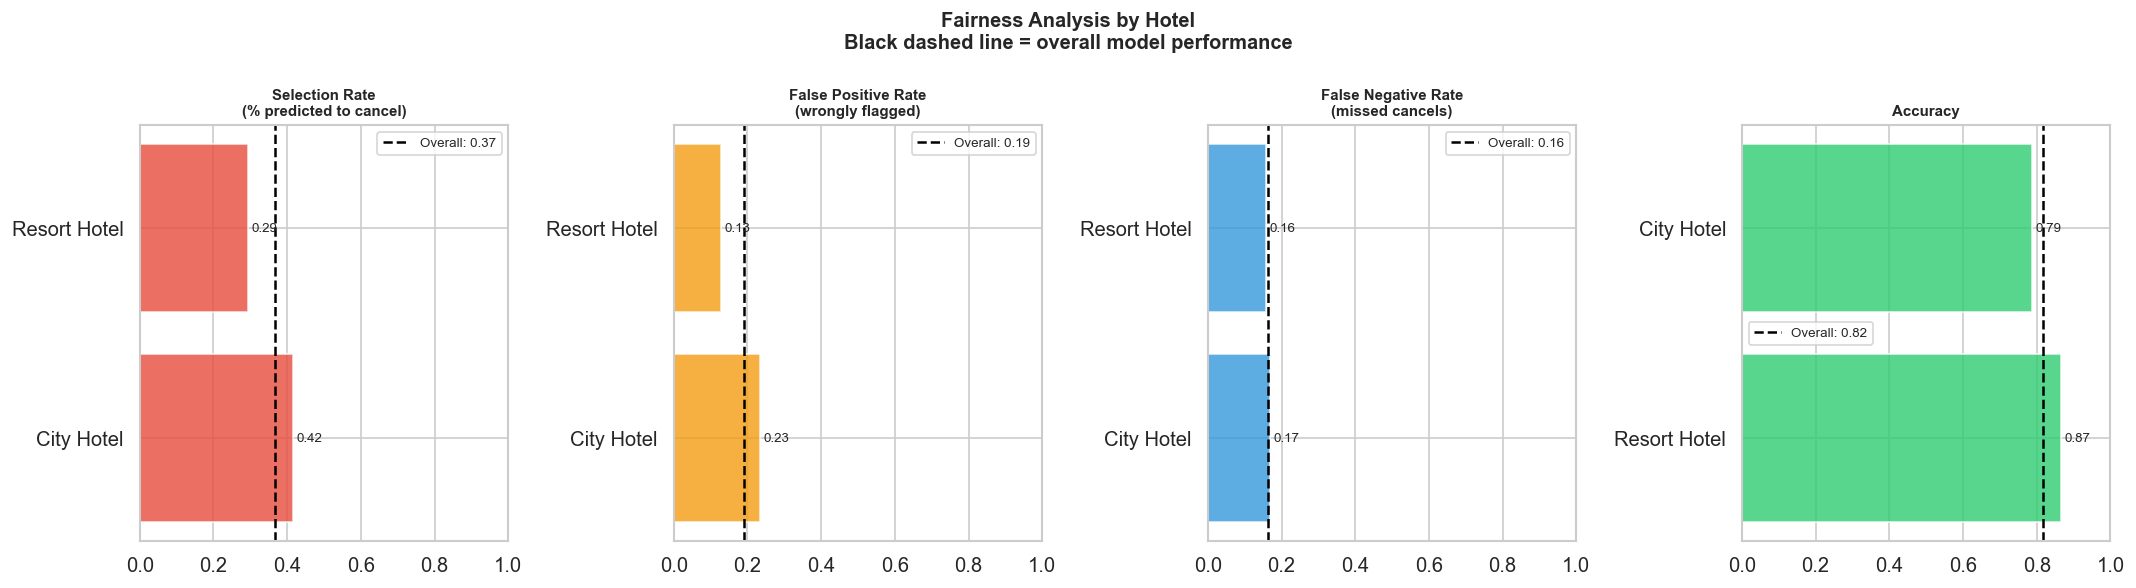

In [30]:
# plot fairness metrics by group for each sensitive attribute
def plot_group_metrics(mf, attr_name, save_path):
    by_group = mf.by_group[[
        'selection_rate', 'false_positive_rate',
        'false_negative_rate', 'accuracy'
    ]].copy()

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    metrics   = [
        ('selection_rate',     'Selection Rate\n(% predicted to cancel)',   '#E74C3C'),
        ('false_positive_rate','False Positive Rate\n(wrongly flagged)',    '#F39C12'),
        ('false_negative_rate','False Negative Rate\n(missed cancels)',     '#3498DB'),
        ('accuracy',           'Accuracy',                                  '#2ECC71'),
    ]

    for ax, (metric, title, color) in zip(axes, metrics):
        vals = by_group[metric].sort_values(ascending=False)
        bars = ax.barh(vals.index.astype(str), vals.values, color=color, alpha=0.8)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.axvline(x=mf.overall[metric], color='black', linestyle='--',
                   linewidth=1.5, label=f'Overall: {mf.overall[metric]:.2f}')
        ax.legend(fontsize=8)
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{width:.2f}', va='center', fontsize=8)

    plt.suptitle(f'Fairness Analysis by {attr_name.replace("_"," ").title()}\n'
                 f'Black dashed line = overall model performance',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()


for attr_name, results in fairness_results.items():
    plot_group_metrics(
        results['metric_frame'],
        attr_name,
        f'explanation_visuals/50_fairness_{attr_name}.png'
    )

In [31]:
# all fairness across all attributes in one table
summary_data = []
for attr, res in fairness_results.items():
    summary_data.append({
        'Sensitive Attribute': attr.replace('_', ' ').title(),
        'DP Difference (lower better)': round(res['dp_difference'], 4),
        'DP Ratio (higher better)': round(res['dp_ratio'],      4),
        'EO Difference (lower better)': round(res['eo_difference'], 4),
        'EO Ratio (higher better)': round(res['eo_ratio'],      4),
        '80% Rule': 'PASS' if res['dp_ratio'] >= 0.8 else 'FAIL'
    })

summary_df = pd.DataFrame(summary_data)
print('Faireness Summary Across All Sensitive Attributes:')
print(summary_df.to_string(index=False))

# Save as CSV for dashboard
summary_df.to_csv('data/fairness_summary.csv', index=False)
print('\nSaved: data/fairness_summary.csv')

Faireness Summary Across All Sensitive Attributes:
Sensitive Attribute  DP Difference (lower better)  DP Ratio (higher better)  EO Difference (lower better)  EO Ratio (higher better) 80% Rule
     Market Segment                        0.4080                    0.1748                        0.5969                    0.1762     FAIL
          Continent                        0.4847                    0.0710                        0.5862                    0.0673     FAIL
       Deposit Type                        0.5995                    0.3749                        0.1731                    0.3077     FAIL
              Hotel                        0.1218                    0.7067                        0.1068                    0.5434     FAIL

Saved: data/fairness_summary.csv


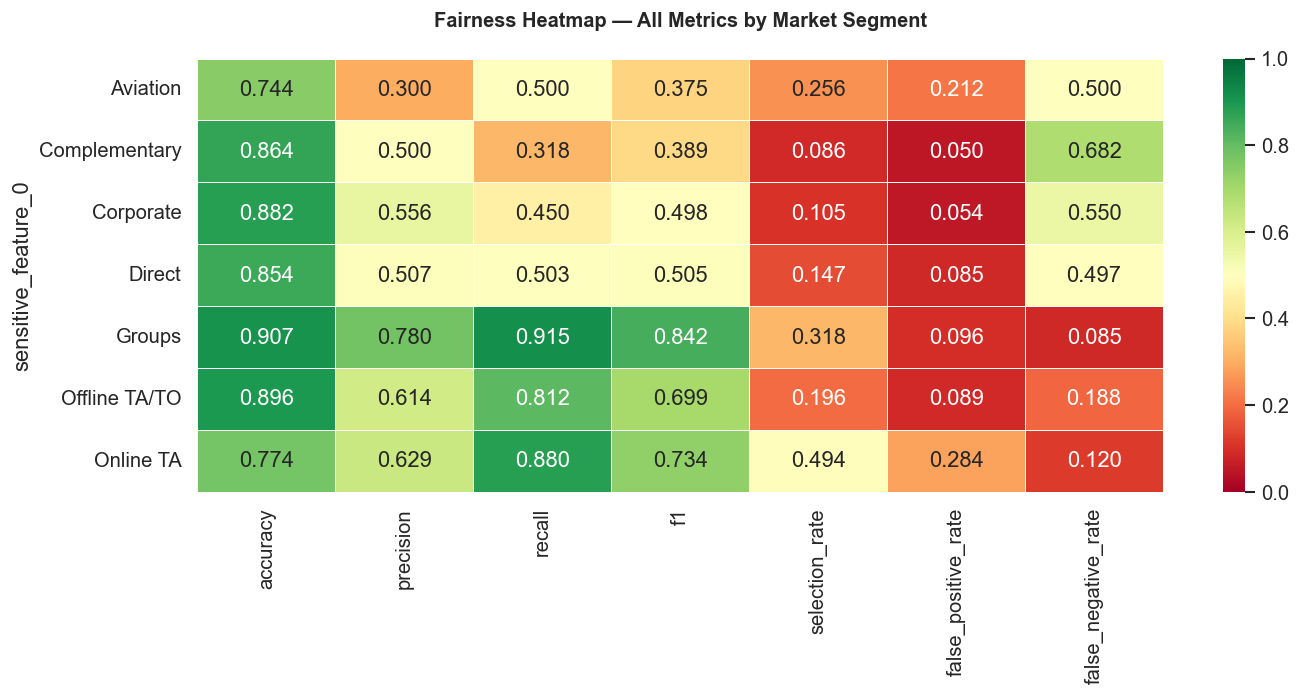

In [32]:
# metric disparity across groups heatmap
# for the most important sensitive attribute (market_segment)
mf_seg = fairness_results['market_segment']['metric_frame']
heatmap_data = mf_seg.by_group[[
    'accuracy', 'precision', 'recall', 'f1',
    'selection_rate', 'false_positive_rate', 'false_negative_rate'
]].round(3)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = '.3f',
    cmap = 'RdYlGn',
    ax = ax,
    linewidths = 0.5,
    vmin = 0,
    vmax = 1
)
ax.set_title('Fairness Heatmap — All Metrics by Market Segment\n',
            fontsize=12, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('explanation_visuals/51_fairness_heatmap.png', bbox_inches='tight')
plt.show()

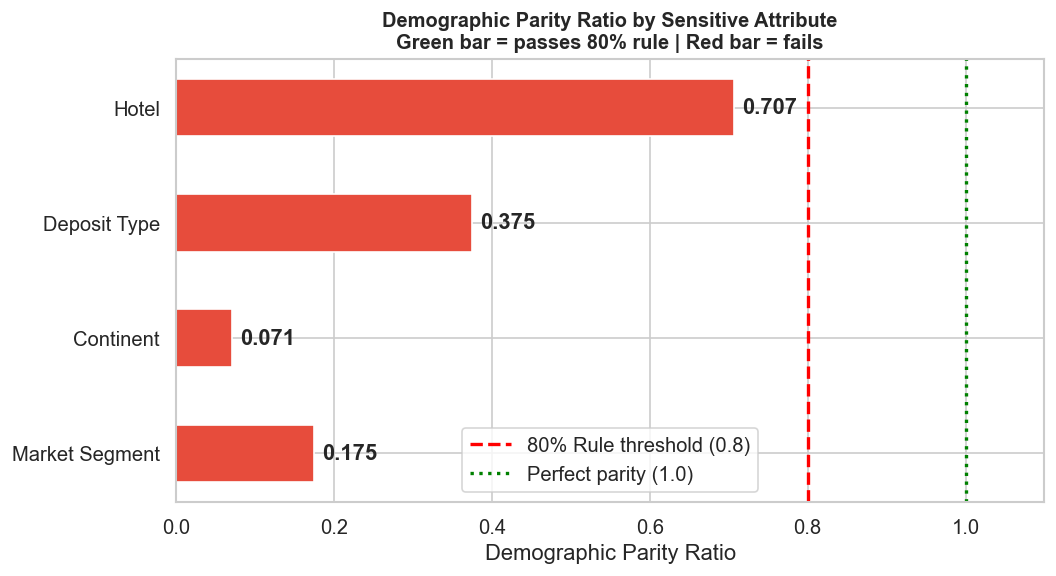

In [33]:
# demographic parity ratio summary plot across all sensitive attributes
fig, ax = plt.subplots(figsize=(9, 5))

attrs  = [a.replace('_',' ').title() for a in fairness_results.keys()]
ratios = [r['dp_ratio'] for r in fairness_results.values()]
colors = ['#2ECC71' if r >= 0.8 else '#E74C3C' for r in ratios]

bars = ax.barh(attrs, ratios, color=colors, height=0.5)
ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2,
           label='80% Rule threshold (0.8)')
ax.axvline(x=1.0, color='green', linestyle=':', linewidth=2,
           label='Perfect parity (1.0)')
ax.set_xlim(0, 1.1)
ax.set_xlabel('Demographic Parity Ratio')
ax.set_title('Demographic Parity Ratio by Sensitive Attribute\n'
             'Green bar = passes 80% rule | Red bar = fails',
             fontsize=12, fontweight='bold')
ax.legend()

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{ratio:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('explanation_visuals/52_dp_ratio_summary.png', bbox_inches='tight')
plt.show()

#### narrative summary

1) What the fairness results show

fairness analysis indicates meaningful group disparities across several attributes:

   - Market Segment: strong disparity (`DP ratio = 0.1748`, `EO ratio = 0.1762`)
   - Continent: very strong disparity (`DP ratio = 0.0710`, `EO ratio = 0.0673`)
   - Deposit Type: strongest demographic-parity gap (`DP diff = 0.5995`)
   - Hotel Type: smaller gap but still below the 80% threshold (`DP ratio = 0.7067`)

Under the 80% rule (`DP ratio > 0.8`), all tested attributes fail, so this model is not fairness-compliant yet if strict parity is required.

2) Why some results appear unfair

Disparity appears for two main reasons:

   - Model relies heavily on group-linked features: SHAP shows `region/continent` and `market_segment` are among the top predictors, so prediction rates naturally differ across groups.

   - Cancelation rate among hotel types differs, city hotels have 30.1% cancelation rate while resort hotels have 23.5% rate

   - Base-rate differences across groups: some groups genuinely have different historical cancellation behavior. This can produce parity gaps even when the model is statistically accurate.

Important: High predictive power explains disparity, but does not automatically justify it from a fairness perspective.

3) How to defend the model responsibly in presentation

   - The model is explaianble with high performance
   - Disparities are partly expected because top features are behaviorally and commercially relevant
   - Prioritizes risk

The current model is accurate and operationally useful, but fairness gaps are real; implement a itigation map
